In [1]:
import duckdb

con = duckdb.connect()
con.sql("SELECT * FROM '../data/raw/accounts.csv' LIMIT 5").show()

IOException: IO Error: No files found that match the pattern "../data/raw/accounts.csv"

In [2]:
import os
print("I'm currently sitting in:", os.getcwd())
print("Files/folders right here:", os.listdir())

I'm currently sitting in: C:\DA projects\Cohort & Retention Analysis
Files/folders right here: ['.ipynb_checkpoints', '01_cohort_analysis.ipynb', 'archive (1).zip', 'ravenstack_accounts.csv', 'ravenstack_churn_events.csv', 'ravenstack_feature_usage.csv', 'ravenstack_subscriptions.csv', 'ravenstack_support_tickets.csv', 'README.md']


In [1]:
import duckdb

con = duckdb.connect()
con.sql("SELECT * FROM '../data/raw/ravenstack_accounts.csv' LIMIT 5").show()

┌────────────┬──────────────┬────────────┬─────────┬─────────────┬─────────────────┬────────────┬───────┬──────────┬────────────┐
│ account_id │ account_name │  industry  │ country │ signup_date │ referral_source │ plan_tier  │ seats │ is_trial │ churn_flag │
│  varchar   │   varchar    │  varchar   │ varchar │    date     │     varchar     │  varchar   │ int64 │ boolean  │  boolean   │
├────────────┼──────────────┼────────────┼─────────┼─────────────┼─────────────────┼────────────┼───────┼──────────┼────────────┤
│ A-2e4581   │ Company_0    │ EdTech     │ US      │ 2024-10-16  │ partner         │ Basic      │     9 │ false    │ false      │
│ A-43a9e3   │ Company_1    │ FinTech    │ IN      │ 2023-08-17  │ other           │ Basic      │    18 │ false    │ true       │
│ A-0a282f   │ Company_2    │ DevTools   │ US      │ 2024-08-27  │ organic         │ Basic      │     1 │ false    │ false      │
│ A-1f0ac7   │ Company_3    │ HealthTech │ UK      │ 2023-08-27  │ other           │ Basic

In [2]:
con.sql("""
    SELECT COUNT(*) AS total_accounts,
           MIN(signup_date) AS earliest_signup,
           MAX(signup_date) AS latest_signup
    FROM '../data/raw/ravenstack_accounts.csv'
""").show()

┌────────────────┬─────────────────┬───────────────┐
│ total_accounts │ earliest_signup │ latest_signup │
│     int64      │      date       │     date      │
├────────────────┼─────────────────┼───────────────┤
│            500 │ 2023-01-02      │ 2024-12-31    │
└────────────────┴─────────────────┴───────────────┘



In [3]:
con.sql("""
    SELECT COUNT(*) AS total_usage_rows,
           MIN(usage_date) AS earliest_activity,
           MAX(usage_date) AS latest_activity,
           COUNT(DISTINCT subscription_id) AS unique_subscriptions
    FROM '../data/raw/ravenstack_feature_usage.csv'
""").show()

┌──────────────────┬───────────────────┬─────────────────┬──────────────────────┐
│ total_usage_rows │ earliest_activity │ latest_activity │ unique_subscriptions │
│      int64       │       date        │      date       │        int64         │
├──────────────────┼───────────────────┼─────────────────┼──────────────────────┤
│            25000 │ 2023-01-01        │ 2024-12-31      │                 4967 │
└──────────────────┴───────────────────┴─────────────────┴──────────────────────┘



In [4]:
con.sql("""
    SELECT COUNT(*) AS total_subscriptions,
           COUNT(DISTINCT account_id) AS unique_accounts_with_subs
    FROM '../data/raw/ravenstack_subscriptions.csv'
""").show()

┌─────────────────────┬───────────────────────────┐
│ total_subscriptions │ unique_accounts_with_subs │
│        int64        │           int64           │
├─────────────────────┼───────────────────────────┤
│                5000 │                       500 │
└─────────────────────┴───────────────────────────┘



In [5]:
con.sql("""
    SELECT
        SUM(CASE WHEN signup_date IS NULL THEN 1 ELSE 0 END) AS null_signups,
        COUNT(*) - COUNT(DISTINCT account_id) AS duplicate_account_ids
    FROM '../data/raw/ravenstack_accounts.csv'
""").show()

┌──────────────┬───────────────────────┐
│ null_signups │ duplicate_account_ids │
│    int128    │         int64         │
├──────────────┼───────────────────────┤
│            0 │                     0 │
└──────────────┴───────────────────────┘



In [6]:
con.sql("""
    SELECT account_id, signup_date,
           DATE_TRUNC('month', signup_date) AS cohort_month
    FROM '../data/raw/ravenstack_accounts.csv'
    LIMIT 5
""").show()

┌────────────┬─────────────┬─────────────────────┐
│ account_id │ signup_date │    cohort_month     │
│  varchar   │    date     │      timestamp      │
├────────────┼─────────────┼─────────────────────┤
│ A-2e4581   │ 2024-10-16  │ 2024-10-01 00:00:00 │
│ A-43a9e3   │ 2023-08-17  │ 2023-08-01 00:00:00 │
│ A-0a282f   │ 2024-08-27  │ 2024-08-01 00:00:00 │
│ A-1f0ac7   │ 2023-08-27  │ 2023-08-01 00:00:00 │
│ A-ce550d   │ 2024-10-27  │ 2024-10-01 00:00:00 │
└────────────┴─────────────┴─────────────────────┘



In [7]:
con.sql("""
    SELECT
        a.account_id,
        DATE_TRUNC('month', a.signup_date) AS cohort_month,
        DATE_TRUNC('month', f.usage_date) AS activity_month,
        DATE_DIFF('month', DATE_TRUNC('month', a.signup_date), DATE_TRUNC('month', f.usage_date)) AS period_number
    FROM '../data/raw/ravenstack_accounts.csv' a
    JOIN '../data/raw/ravenstack_subscriptions.csv' s ON a.account_id = s.account_id
    JOIN '../data/raw/ravenstack_feature_usage.csv' f ON s.subscription_id = f.subscription_id
    LIMIT 10
""").show()

┌────────────┬─────────────────────┬─────────────────────┬───────────────┐
│ account_id │    cohort_month     │   activity_month    │ period_number │
│  varchar   │      timestamp      │      timestamp      │     int64     │
├────────────┼─────────────────────┼─────────────────────┼───────────────┤
│ A-e08cd3   │ 2024-09-01 00:00:00 │ 2023-07-01 00:00:00 │           -14 │
│ A-c7ffc2   │ 2023-01-01 00:00:00 │ 2023-08-01 00:00:00 │             7 │
│ A-bbe56f   │ 2023-02-01 00:00:00 │ 2023-12-01 00:00:00 │            10 │
│ A-7f29a7   │ 2024-09-01 00:00:00 │ 2024-07-01 00:00:00 │            -2 │
│ A-65a46c   │ 2023-11-01 00:00:00 │ 2024-12-01 00:00:00 │            13 │
│ A-417d2f   │ 2023-07-01 00:00:00 │ 2023-10-01 00:00:00 │             3 │
│ A-5b4ebb   │ 2024-07-01 00:00:00 │ 2023-09-01 00:00:00 │           -10 │
│ A-eb1312   │ 2024-09-01 00:00:00 │ 2023-06-01 00:00:00 │           -15 │
│ A-f25509   │ 2024-03-01 00:00:00 │ 2024-02-01 00:00:00 │            -1 │
│ A-89ee83   │ 2024-10-01

In [8]:
con.sql("""
    SELECT
        COUNT(*) AS total_activity_rows,
        SUM(CASE WHEN DATE_DIFF('month', DATE_TRUNC('month', a.signup_date), DATE_TRUNC('month', f.usage_date)) < 0
            THEN 1 ELSE 0 END) AS negative_period_rows,
        ROUND(SUM(CASE WHEN DATE_DIFF('month', DATE_TRUNC('month', a.signup_date), DATE_TRUNC('month', f.usage_date)) < 0
            THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_negative
    FROM '../data/raw/ravenstack_accounts.csv' a
    JOIN '../data/raw/ravenstack_subscriptions.csv' s ON a.account_id = s.account_id
    JOIN '../data/raw/ravenstack_feature_usage.csv' f ON s.subscription_id = f.subscription_id
""").show()

┌─────────────────────┬──────────────────────┬──────────────┐
│ total_activity_rows │ negative_period_rows │ pct_negative │
│        int64        │        int128        │    double    │
├─────────────────────┼──────────────────────┼──────────────┤
│               25000 │                12674 │         50.7 │
└─────────────────────┴──────────────────────┴──────────────┘



In [9]:
con.sql("""
    SELECT
        COUNT(*) AS total_subscriptions,
        SUM(CASE WHEN s.start_date < a.signup_date THEN 1 ELSE 0 END) AS subs_starting_before_signup,
        ROUND(SUM(CASE WHEN s.start_date < a.signup_date THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct
    FROM '../data/raw/ravenstack_accounts.csv' a
    JOIN '../data/raw/ravenstack_subscriptions.csv' s ON a.account_id = s.account_id
""").show()

┌─────────────────────┬─────────────────────────────┬────────┐
│ total_subscriptions │ subs_starting_before_signup │  pct   │
│        int64        │           int128            │ double │
├─────────────────────┼─────────────────────────────┼────────┤
│                5000 │                           0 │    0.0 │
└─────────────────────┴─────────────────────────────┴────────┘



In [10]:
con.sql("""
    SELECT
        COUNT(*) AS total_usage_rows,
        SUM(CASE WHEN f.usage_date < s.start_date THEN 1 ELSE 0 END) AS usage_before_sub_start,
        ROUND(SUM(CASE WHEN f.usage_date < s.start_date THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct
    FROM '../data/raw/ravenstack_subscriptions.csv' s
    JOIN '../data/raw/ravenstack_feature_usage.csv' f ON s.subscription_id = f.subscription_id
""").show()

┌──────────────────┬────────────────────────┬────────┐
│ total_usage_rows │ usage_before_sub_start │  pct   │
│      int64       │         int128         │ double │
├──────────────────┼────────────────────────┼────────┤
│            25000 │                  19142 │  76.57 │
└──────────────────┴────────────────────────┴────────┘



In [11]:
con.sql("""
    SELECT subscription_id, account_id, start_date, end_date, churn_flag
    FROM '../data/raw/ravenstack_subscriptions.csv'
    LIMIT 10
""").show()

┌─────────────────┬────────────┬────────────┬────────────┬────────────┐
│ subscription_id │ account_id │ start_date │  end_date  │ churn_flag │
│     varchar     │  varchar   │    date    │    date    │  boolean   │
├─────────────────┼────────────┼────────────┼────────────┼────────────┤
│ S-8cec59        │ A-3c1a3f   │ 2023-12-23 │ 2024-04-12 │ true       │
│ S-0f6f44        │ A-9b9fe9   │ 2024-06-11 │ NULL       │ false      │
│ S-51c0d1        │ A-659280   │ 2024-11-25 │ NULL       │ false      │
│ S-f81687        │ A-e7a1e2   │ 2024-11-23 │ 2024-12-13 │ true       │
│ S-cff5a2        │ A-ba6516   │ 2024-01-10 │ NULL       │ false      │
│ S-4b9b13        │ A-fa2041   │ 2024-08-13 │ NULL       │ false      │
│ S-dceac6        │ A-417d2f   │ 2023-12-30 │ NULL       │ false      │
│ S-8cad7b        │ A-5f2961   │ 2024-12-23 │ NULL       │ false      │
│ S-24796e        │ A-cc8c8f   │ 2024-11-27 │ NULL       │ false      │
│ S-d0c344        │ A-80eeb6   │ 2024-10-27 │ NULL       │ false

In [16]:
con.sql("""
    SELECT
        s.account_id,
        s.subscription_id,
        UNNEST(GENERATE_SERIES(
            DATE_TRUNC('month', s.start_date),
            DATE_TRUNC('month', COALESCE(s.end_date, DATE '2024-12-31')),
            INTERVAL 1 MONTH
        )) AS active_month
    FROM '../data/raw/ravenstack_subscriptions.csv' s
    LIMIT 20
""").show()

┌────────────┬─────────────────┬─────────────────────┐
│ account_id │ subscription_id │    active_month     │
│  varchar   │     varchar     │      timestamp      │
├────────────┼─────────────────┼─────────────────────┤
│ A-3c1a3f   │ S-8cec59        │ 2023-12-01 00:00:00 │
│ A-3c1a3f   │ S-8cec59        │ 2024-01-01 00:00:00 │
│ A-3c1a3f   │ S-8cec59        │ 2024-02-01 00:00:00 │
│ A-3c1a3f   │ S-8cec59        │ 2024-03-01 00:00:00 │
│ A-3c1a3f   │ S-8cec59        │ 2024-04-01 00:00:00 │
│ A-9b9fe9   │ S-0f6f44        │ 2024-06-01 00:00:00 │
│ A-9b9fe9   │ S-0f6f44        │ 2024-07-01 00:00:00 │
│ A-9b9fe9   │ S-0f6f44        │ 2024-08-01 00:00:00 │
│ A-9b9fe9   │ S-0f6f44        │ 2024-09-01 00:00:00 │
│ A-9b9fe9   │ S-0f6f44        │ 2024-10-01 00:00:00 │
│ A-9b9fe9   │ S-0f6f44        │ 2024-11-01 00:00:00 │
│ A-9b9fe9   │ S-0f6f44        │ 2024-12-01 00:00:00 │
│ A-659280   │ S-51c0d1        │ 2024-11-01 00:00:00 │
│ A-659280   │ S-51c0d1        │ 2024-12-01 00:00:00 │
│ A-e7a1e2

In [17]:
retention_query = """
WITH cohorts AS (
    SELECT account_id, DATE_TRUNC('month', signup_date) AS cohort_month
    FROM '../data/raw/ravenstack_accounts.csv'
),
active_months AS (
    SELECT DISTINCT
        s.account_id,
        UNNEST(GENERATE_SERIES(
            DATE_TRUNC('month', s.start_date),
            DATE_TRUNC('month', COALESCE(s.end_date, DATE '2024-12-31')),
            INTERVAL 1 MONTH
        )) AS active_month
    FROM '../data/raw/ravenstack_subscriptions.csv' s
),
cohort_activity AS (
    SELECT
        c.cohort_month,
        DATE_DIFF('month', c.cohort_month, am.active_month) AS period_number,
        am.account_id
    FROM cohorts c
    JOIN active_months am ON c.account_id = am.account_id
    WHERE am.active_month >= c.cohort_month
),
cohort_size AS (
    SELECT cohort_month, COUNT(DISTINCT account_id) AS num_accounts
    FROM cohorts
    GROUP BY cohort_month
)
SELECT
    ca.cohort_month,
    ca.period_number,
    COUNT(DISTINCT ca.account_id) AS active_accounts,
    cs.num_accounts AS cohort_size,
    ROUND(COUNT(DISTINCT ca.account_id) * 100.0 / cs.num_accounts, 1) AS retention_pct
FROM cohort_activity ca
JOIN cohort_size cs ON ca.cohort_month = cs.cohort_month
GROUP BY ca.cohort_month, ca.period_number, cs.num_accounts
ORDER BY ca.cohort_month, ca.period_number
"""

retention_df = con.sql(retention_query).df()
retention_df.head(20)

,cohort_month,period_number,active_accounts,cohort_size,retention_pct
0,2023-01-01,0,2,17,11.8
1,2023-01-01,1,7,17,41.2
2,2023-01-01,2,9,17,52.9
3,2023-01-01,3,12,17,70.6
4,2023-01-01,4,14,17,82.4
5,2023-01-01,5,14,17,82.4
6,2023-01-01,6,15,17,88.2
7,2023-01-01,7,16,17,94.1
8,2023-01-01,8,16,17,94.1
9,2023-01-01,9,16,17,94.1


In [18]:
con.sql("""
    SELECT
        a.account_id,
        a.signup_date,
        MIN(s.start_date) AS first_subscription_start,
        DATE_DIFF('month', DATE_TRUNC('month', a.signup_date), DATE_TRUNC('month', MIN(s.start_date))) AS months_gap
    FROM '../data/raw/ravenstack_accounts.csv' a
    JOIN '../data/raw/ravenstack_subscriptions.csv' s ON a.account_id = s.account_id
    WHERE DATE_TRUNC('month', a.signup_date) = DATE '2023-01-01'
    GROUP BY a.account_id, a.signup_date
    ORDER BY months_gap DESC
""").show()

┌────────────┬─────────────┬──────────────────────────┬────────────┐
│ account_id │ signup_date │ first_subscription_start │ months_gap │
│  varchar   │    date     │           date           │   int64    │
├────────────┼─────────────┼──────────────────────────┼────────────┤
│ A-f19b24   │ 2023-01-10  │ 2024-03-17               │         14 │
│ A-91e948   │ 2023-01-29  │ 2023-08-14               │          7 │
│ A-1986ca   │ 2023-01-30  │ 2023-07-06               │          6 │
│ A-c7ffc2   │ 2023-01-27  │ 2023-05-25               │          4 │
│ A-151c9a   │ 2023-01-27  │ 2023-05-08               │          4 │
│ A-3b37d9   │ 2023-01-27  │ 2023-04-11               │          3 │
│ A-ff3c73   │ 2023-01-26  │ 2023-04-06               │          3 │
│ A-32728c   │ 2023-01-03  │ 2023-04-04               │          3 │
│ A-b9f5b1   │ 2023-01-24  │ 2023-03-12               │          2 │
│ A-ed510f   │ 2023-01-17  │ 2023-03-09               │          2 │
│ A-7df7a7   │ 2023-01-28  │ 2023-

In [21]:
print(retention_df[retention_df['period_number'] == 0][['cohort_month', 'cohort_size']])

    cohort_month  cohort_size
0     2023-01-01            2
24    2023-02-01            8
47    2023-03-01           11
69    2023-04-01           15
90    2023-05-01           14
110   2023-06-01           21
129   2023-07-01           18
147   2023-08-01           27
164   2023-09-01           15
180   2023-10-01           18
195   2023-11-01           22
209   2023-12-01           20
222   2024-01-01           26
234   2024-02-01           18
245   2024-03-01           25
255   2024-04-01           22
264   2024-05-01           28
272   2024-06-01           27
279   2024-07-01           28
285   2024-08-01           20
290   2024-09-01           31
294   2024-10-01           23
297   2024-11-01           36
299   2024-12-01           25


In [22]:
print(retention_df.groupby('period_number')['retention_pct'].mean().head(15))

period_number
0     100.000000
1     100.000000
2     100.000000
3      99.680952
4     100.000000
5     100.000000
6     100.000000
7     100.000000
8     100.000000
9     100.000000
10    100.000000
11    100.000000
12    100.000000
13    100.000000
14    100.000000
Name: retention_pct, dtype: float64


In [23]:
retention_query = """
WITH cohorts AS (
    SELECT s.account_id, DATE_TRUNC('month', MIN(s.start_date)) AS cohort_month
    FROM '../data/raw/ravenstack_subscriptions.csv' s
    GROUP BY s.account_id
),
active_months AS (
    SELECT DISTINCT
        s.account_id,
        UNNEST(GENERATE_SERIES(
            DATE_TRUNC('month', s.start_date),
            DATE_TRUNC('month', COALESCE(s.end_date, DATE '2024-12-31')),
            INTERVAL 1 MONTH
        )) AS active_month
    FROM '../data/raw/ravenstack_subscriptions.csv' s
),
calendar AS (
    -- every account gets one row per month, from their cohort month through Dec 2024
    SELECT c.account_id, c.cohort_month,
           UNNEST(GENERATE_SERIES(c.cohort_month, DATE '2024-12-01', INTERVAL 1 MONTH)) AS calendar_month
    FROM cohorts c
),
coverage AS (
    -- flag 1 if that account had a subscription covering that month, else 0
    SELECT
        cal.account_id, cal.cohort_month, cal.calendar_month,
        DATE_DIFF('month', cal.cohort_month, cal.calendar_month) AS period_number,
        CASE WHEN am.active_month IS NOT NULL THEN 1 ELSE 0 END AS is_covered
    FROM calendar cal
    LEFT JOIN active_months am
        ON cal.account_id = am.account_id AND cal.calendar_month = am.active_month
),
retained AS (
    -- the "streak tracker": once is_covered hits 0 once, this stays 0 forever after
    SELECT *,
        MIN(is_covered) OVER (PARTITION BY account_id ORDER BY calendar_month
                               ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS still_retained
    FROM coverage
),
cohort_size AS (
    SELECT cohort_month, COUNT(DISTINCT account_id) AS num_accounts
    FROM cohorts GROUP BY cohort_month
)
SELECT
    r.cohort_month, r.period_number,
    SUM(r.still_retained) AS active_accounts,
    cs.num_accounts AS cohort_size,
    ROUND(SUM(r.still_retained) * 100.0 /

_IncompleteInputError: incomplete input (3532685790.py, line 1)

In [24]:
retention_df = con.sql(retention_query).df()
retention_df.groupby('period_number')['retention_pct'].mean().head(15)

period_number
0     100.000000
1     100.000000
2     100.000000
3      99.680952
4     100.000000
5     100.000000
6     100.000000
7     100.000000
8     100.000000
9     100.000000
10    100.000000
11    100.000000
12    100.000000
13    100.000000
14    100.000000
Name: retention_pct, dtype: float64

In [25]:
print(retention_df.groupby('period_number')['retention_pct'].mean())

period_number
0     100.000000
1     100.000000
2     100.000000
3      99.680952
4     100.000000
5     100.000000
6     100.000000
7     100.000000
8     100.000000
9     100.000000
10    100.000000
11    100.000000
12    100.000000
13    100.000000
14    100.000000
15    100.000000
16    100.000000
17    100.000000
18    100.000000
19    100.000000
20    100.000000
21    100.000000
22    100.000000
23    100.000000
Name: retention_pct, dtype: float64


In [26]:
con.sql("SELECT * FROM '../data/raw/ravenstack_churn_events.csv' LIMIT 5").show()

┌────────────────┬────────────┬────────────┬─────────────┬───────────────────┬────────────────────────┬──────────────────────────┬─────────────────┬────────────────────────┐
│ churn_event_id │ account_id │ churn_date │ reason_code │ refund_amount_usd │ preceding_upgrade_flag │ preceding_downgrade_flag │ is_reactivation │     feedback_text      │
│    varchar     │  varchar   │    date    │   varchar   │      double       │        boolean         │         boolean          │     boolean     │        varchar         │
├────────────────┼────────────┼────────────┼─────────────┼───────────────────┼────────────────────────┼──────────────────────────┼─────────────────┼────────────────────────┤
│ C-816288       │ A-c37cab   │ 2024-10-27 │ pricing     │              4.03 │ false                  │ false                    │ false           │ switched to competitor │
│ C-5a81e7       │ A-37f969   │ 2024-06-25 │ support     │             96.45 │ true                   │ false                    │

In [27]:
con.sql("""
    SELECT COUNT(*) AS total_churn_events,
           COUNT(DISTINCT account_id) AS unique_churned_accounts
    FROM '../data/raw/ravenstack_churn_events.csv'
""").show()

┌────────────────────┬─────────────────────────┐
│ total_churn_events │ unique_churned_accounts │
│       int64        │          int64          │
├────────────────────┼─────────────────────────┤
│                600 │                     352 │
└────────────────────┴─────────────────────────┘



In [28]:
retention_query = """
WITH cohorts AS (
    SELECT s.account_id, DATE_TRUNC('month', MIN(s.start_date)) AS cohort_month
    FROM '../data/raw/ravenstack_subscriptions.csv' s
    GROUP BY s.account_id
),
first_churn AS (
    -- each account's FIRST churn date (their initial true departure)
    SELECT account_id, MIN(churn_date) AS first_churn_date
    FROM '../data/raw/ravenstack_churn_events.csv'
    GROUP BY account_id
),
calendar AS (
    SELECT c.account_id, c.cohort_month,
           UNNEST(GENERATE_SERIES(c.cohort_month, DATE '2024-12-01', INTERVAL 1 MONTH)) AS calendar_month
    FROM cohorts c
),
retained AS (
    SELECT
        cal.account_id, cal.cohort_month, cal.calendar_month,
        DATE_DIFF('month', cal.cohort_month, cal.calendar_month) AS period_number,
        CASE
            WHEN fc.first_churn_date IS NULL THEN 1                                    -- never churned
            WHEN cal.calendar_month < DATE_TRUNC('month', fc.first_churn_date) THEN 1  -- still before they left
            ELSE 0                                                                     -- churned by now
        END AS is_retained
    FROM calendar cal
    LEFT JOIN first_churn fc ON cal.account_id = fc.account_id
),
cohort_size AS (
    SELECT cohort_month, COUNT(DISTINCT account_id) AS num_accounts
    FROM cohorts GROUP BY cohort_month
)
SELECT
    r.cohort_month, r.period_number,
    SUM(r.is_retained) AS active_accounts,
    cs.num_accounts AS cohort_size,
    ROUND(SUM(r.is_retained) * 100.0 / cs.num_accounts, 1) AS retention_pct
FROM retained r
JOIN cohort_size cs ON r.cohort_month = cs.cohort_month
GROUP BY r.cohort_month, r.period_number, cs.num_accounts
ORDER BY r.cohort_month, r.period_number
"""

retention_df = con.sql(retention_query).df()
print(retention_df.groupby('period_number')['retention_pct'].mean())

period_number
0     82.037500
1     72.334783
2     66.668182
3     61.909524
4     57.420000
5     56.594737
6     54.344444
7     50.823529
8     48.381250
9     44.473333
10    43.285714
11    41.284615
12    40.900000
13    41.109091
14    39.430000
15    41.833333
16    39.062500
17    34.785714
18    35.950000
19    33.780000
20    33.300000
21    31.066667
22    37.500000
23    50.000000
Name: retention_pct, dtype: float64


FileNotFoundError: [Errno 2] No such file or directory: '../images/cohort_retention_heatmap.png'

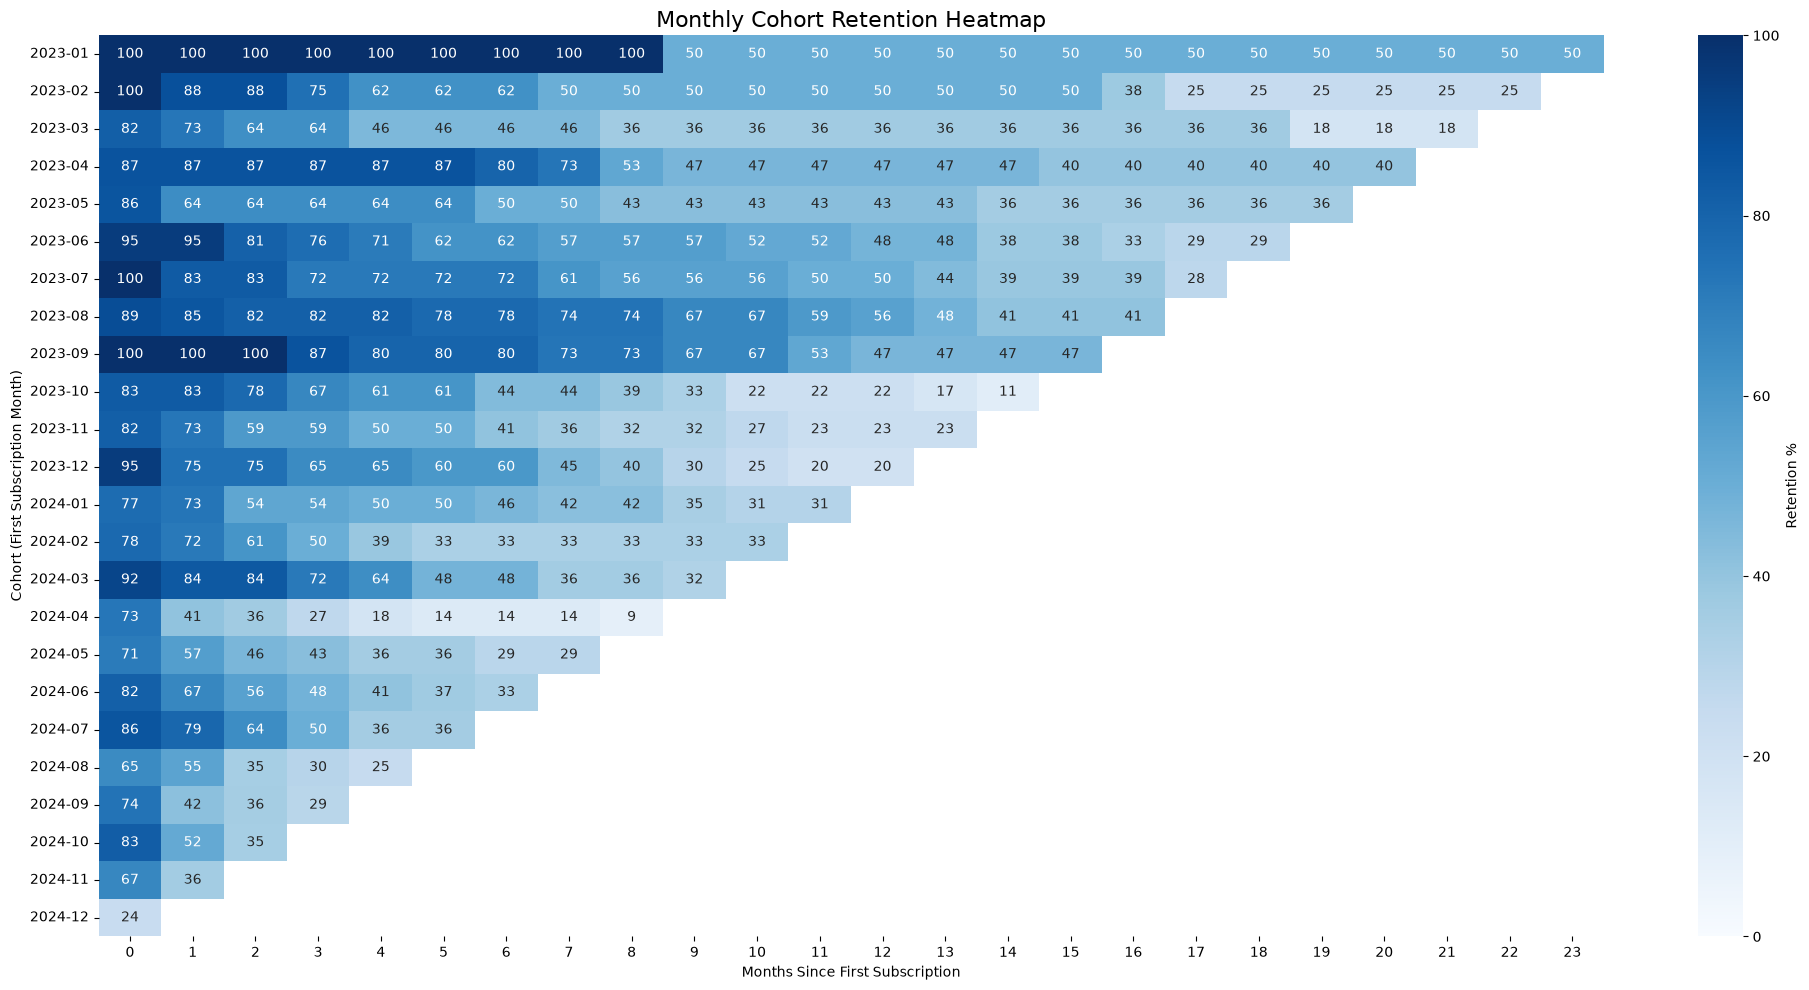

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# format cohort labels nicely (e.g. "2023-01" instead of a full timestamp)
retention_df['cohort_label'] = retention_df['cohort_month'].dt.strftime('%Y-%m')

# reshape from long format (one row per cohort+period) into a matrix:
# rows = cohorts, columns = period number, values = retention %
cohort_pivot = retention_df.pivot(index='cohort_label', columns='period_number', values='retention_pct')

plt.figure(figsize=(20, 10))
sns.heatmap(cohort_pivot, annot=True, fmt='.0f', cmap='Blues',
            vmin=0, vmax=100, cbar_kws={'label': 'Retention %'})
plt.title('Monthly Cohort Retention Heatmap', fontsize=16)
plt.xlabel('Months Since First Subscription')
plt.ylabel('Cohort (First Subscription Month)')
plt.tight_layout()
plt.savefig('../images/cohort_retention_heatmap.png', dpi=150)
plt.show()

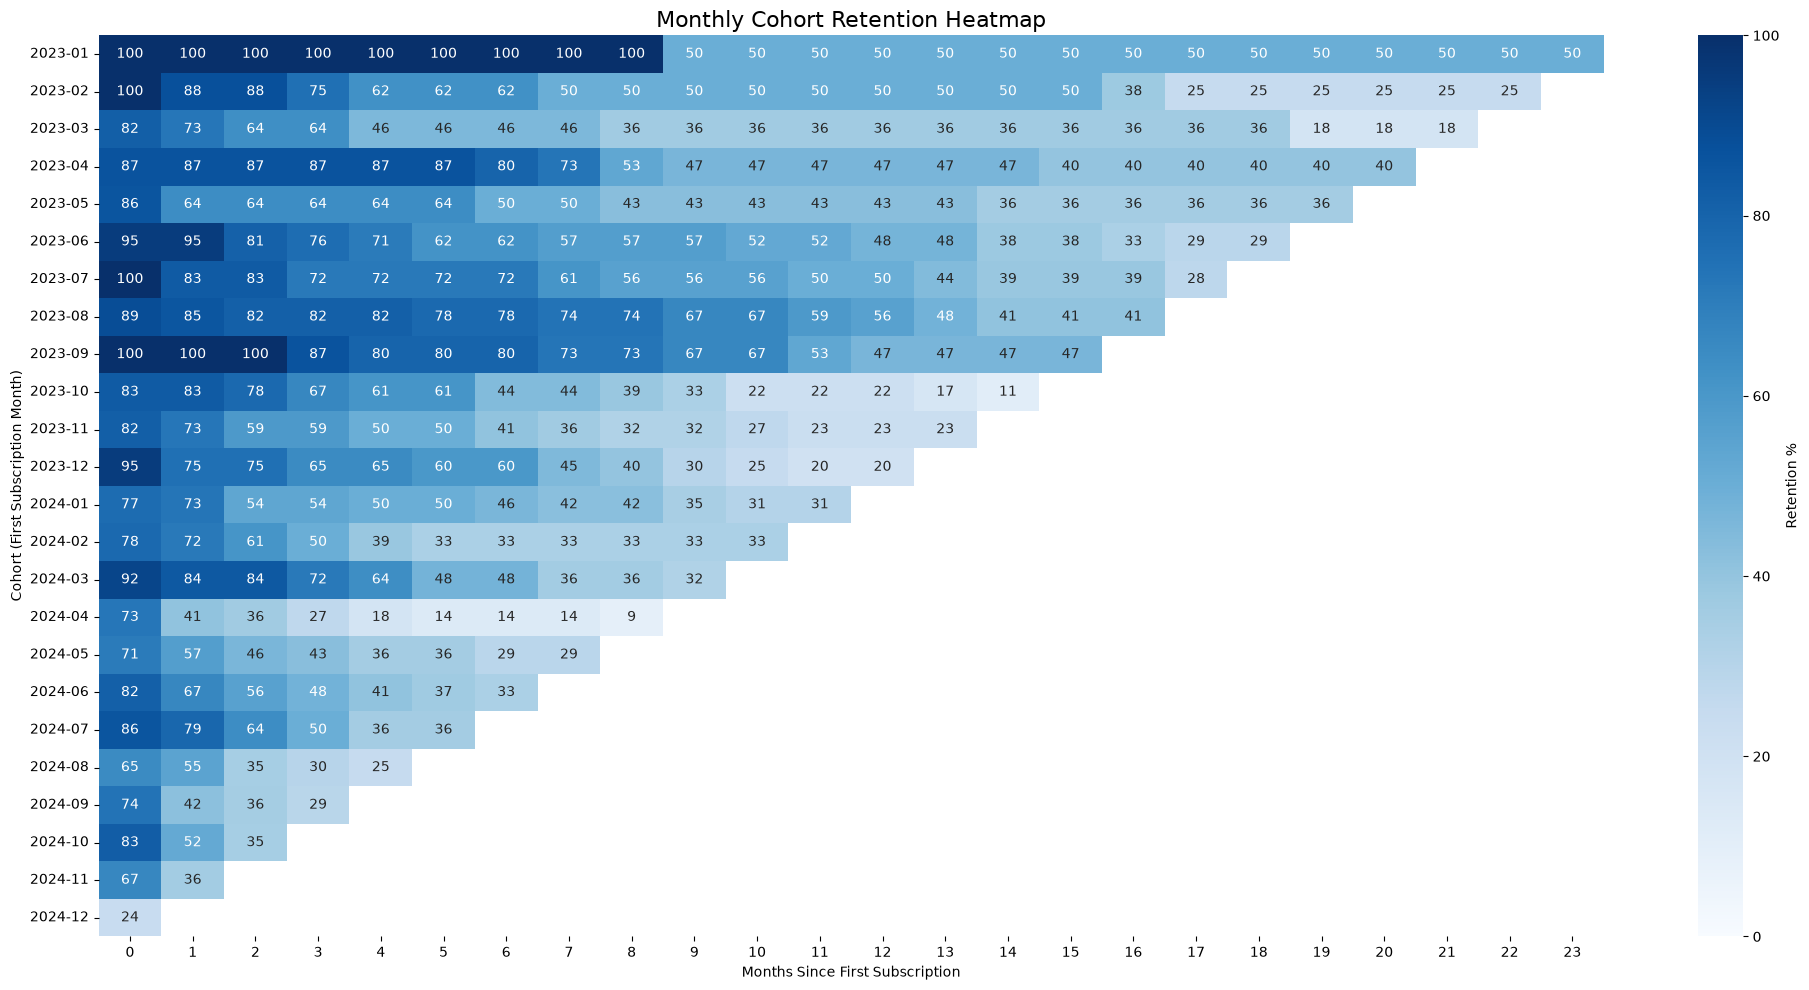

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# format cohort labels nicely (e.g. "2023-01" instead of a full timestamp)
retention_df['cohort_label'] = retention_df['cohort_month'].dt.strftime('%Y-%m')

# reshape from long format (one row per cohort+period) into a matrix:
# rows = cohorts, columns = period number, values = retention %
cohort_pivot = retention_df.pivot(index='cohort_label', columns='period_number', values='retention_pct')

plt.figure(figsize=(20, 10))
sns.heatmap(cohort_pivot, annot=True, fmt='.0f', cmap='Blues',
            vmin=0, vmax=100, cbar_kws={'label': 'Retention %'})
plt.title('Monthly Cohort Retention Heatmap', fontsize=16)
plt.xlabel('Months Since First Subscription')
plt.ylabel('Cohort (First Subscription Month)')
plt.tight_layout()
plt.savefig('../images/cohort_retention_heatmap.png', dpi=150)
plt.show()

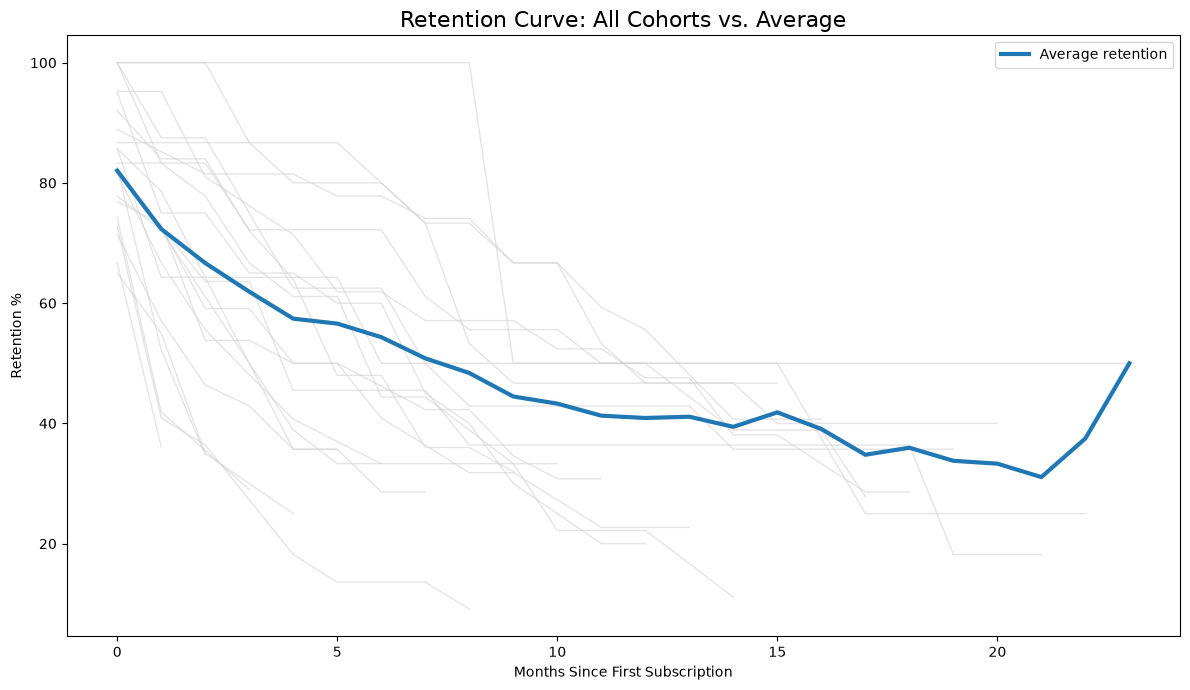

In [33]:
plt.figure(figsize=(12, 7))

# every individual cohort as a faint gray line (context, not the focus)
for cohort in retention_df['cohort_label'].unique():
    cohort_data = retention_df[retention_df['cohort_label'] == cohort]
    plt.plot(cohort_data['period_number'], cohort_data['retention_pct'],
              color='lightgray', linewidth=1, alpha=0.6)

# bold average line on top — the main story
avg_curve = retention_df.groupby('period_number')['retention_pct'].mean()
plt.plot(avg_curve.index, avg_curve.values, color='#1f77b4', linewidth=3, label='Average retention')

plt.title('Retention Curve: All Cohorts vs. Average', fontsize=16)
plt.xlabel('Months Since First Subscription')
plt.ylabel('Retention %')
plt.legend()
plt.tight_layout()
plt.savefig('../images/retention_curve.png', dpi=150)
plt.show()

In [34]:
plan_retention_query = """
WITH first_sub AS (
    SELECT account_id, start_date, plan_tier,
           ROW_NUMBER() OVER (PARTITION BY account_id ORDER BY start_date) AS rn
    FROM '../data/raw/ravenstack_subscriptions.csv'
),
cohorts AS (
    SELECT account_id, DATE_TRUNC('month', start_date) AS cohort_month, plan_tier AS starting_plan
    FROM first_sub WHERE rn = 1
),
first_churn AS (
    SELECT account_id, MIN(churn_date) AS first_churn_date
    FROM '../data/raw/ravenstack_churn_events.csv'
    GROUP BY account_id
),
calendar AS (
    SELECT c.account_id, c.cohort_month, c.starting_plan,
           UNNEST(GENERATE_SERIES(c.cohort_month, DATE '2024-12-01', INTERVAL 1 MONTH)) AS calendar_month
    FROM cohorts c
),
retained AS (
    SELECT cal.account_id, cal.starting_plan,
        DATE_DIFF('month', cal.cohort_month, cal.calendar_month) AS period_number,
        CASE
            WHEN fc.first_churn_date IS NULL THEN 1
            WHEN cal.calendar_month < DATE_TRUNC('month', fc.first_churn_date) THEN 1
            ELSE 0
        END AS is_retained
    FROM calendar cal
    LEFT JOIN first_churn fc ON cal.account_id = fc.account_id
),
plan_size AS (
    SELECT starting_plan, COUNT(DISTINCT account_id) AS num_accounts
    FROM cohorts GROUP BY starting_plan
)
SELECT r.starting_plan, r.period_number,
    SUM(r.is_retained) AS active_accounts,
    ps.num_accounts AS plan_size,
    ROUND(SUM(r.is_retained) * 100.0 / ps.num_accounts, 1) AS retention_pct
FROM retained r
JOIN plan_size ps ON r.starting_plan = ps.starting_plan
GROUP BY r.starting_plan, r.period_number, ps.num_accounts
ORDER BY r.starting_plan, r.period_number
"""

plan_retention_df = con.sql(plan_retention_query).df()
plan_retention_df.head(10)

,starting_plan,period_number,active_accounts,plan_size,retention_pct
0,Basic,0,130.0,163,79.8
1,Basic,1,108.0,163,66.3
2,Basic,2,95.0,163,58.3
3,Basic,3,82.0,163,50.3
4,Basic,4,74.0,163,45.4
5,Basic,5,67.0,163,41.1
6,Basic,6,62.0,163,38.0
7,Basic,7,53.0,163,32.5
8,Basic,8,45.0,163,27.6
9,Basic,9,40.0,163,24.5


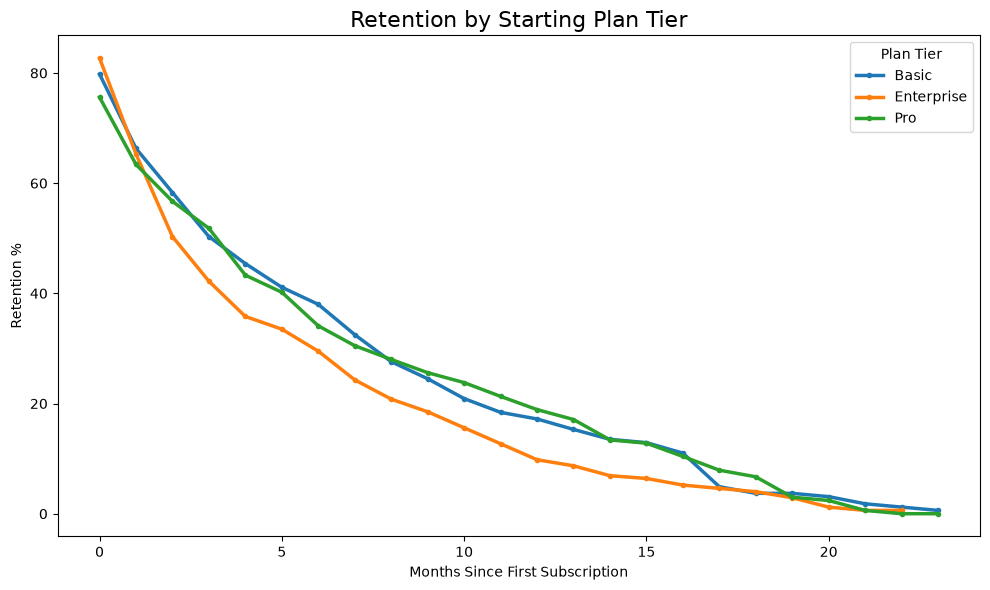

In [35]:
plt.figure(figsize=(10, 6))

for plan in plan_retention_df['starting_plan'].unique():
    plan_data = plan_retention_df[plan_retention_df['starting_plan'] == plan]
    plt.plot(plan_data['period_number'], plan_data['retention_pct'], linewidth=2.5, marker='o', markersize=3, label=plan)

plt.title('Retention by Starting Plan Tier', fontsize=16)
plt.xlabel('Months Since First Subscription')
plt.ylabel('Retention %')
plt.legend(title='Plan Tier')
plt.tight_layout()
plt.savefig('../images/retention_by_plan.png', dpi=150)
plt.show()

In [36]:
account_summary_query = """
WITH first_sub AS (
    SELECT account_id, start_date, plan_tier, seats, mrr_amount,
           ROW_NUMBER() OVER (PARTITION BY account_id ORDER BY start_date) AS rn
    FROM '../data/raw/ravenstack_subscriptions.csv'
),
cohorts AS (
    SELECT account_id, DATE_TRUNC('month', start_date) AS cohort_month,
           plan_tier AS starting_plan, seats AS starting_seats, mrr_amount AS starting_mrr
    FROM first_sub WHERE rn = 1
),
first_churn AS (
    SELECT account_id, MIN(churn_date) AS first_churn_date
    FROM '../data/raw/ravenstack_churn_events.csv'
    GROUP BY account_id
),
churn_reason AS (
    SELECT ce.account_id, ce.reason_code
    FROM '../data/raw/ravenstack_churn_events.csv' ce
    JOIN first_churn fc ON ce.account_id = fc.account_id AND ce.churn_date = fc.first_churn_date
)
SELECT
    a.account_id, a.industry, a.country, a.referral_source,
    c.cohort_month, c.starting_plan, c.starting_seats, c.starting_mrr,
    CASE WHEN fc.first_churn_date IS NULL THEN 'Active' ELSE 'Churned' END AS current_status,
    fc.first_churn_date,
    cr.reason_code AS churn_reason,
    CASE
        WHEN fc.first_churn_date IS NULL THEN DATE_DIFF('month', c.cohort_month, DATE '2024-12-01')
        ELSE DATE_DIFF('month', c.cohort_month, DATE_TRUNC('month', fc.first_churn_date))
    END AS months_active
FROM '../data/raw/ravenstack_accounts.csv' a
JOIN cohorts c ON a.account_id = c.account_id
LEFT JOIN first_churn fc ON a.account_id = fc.account_id
LEFT JOIN churn_reason cr ON a.account_id = cr.account_id
ORDER BY c.cohort_month, a.account_id
"""

account_summary_df = con.sql(account_summary_query).df()

# export both this AND our already-built retention table, ready for Tableau
account_summary_df.to_csv('../data/processed/account_summary.csv', index=False)
retention_df.to_csv('../data/processed/cohort_retention.csv', index=False)

account_summary_df.head(10)

,account_id,industry,country,referral_source,cohort_month,starting_plan,starting_seats,starting_mrr,current_status,first_churn_date,churn_reason,months_active
0,A-779e4e,HealthTech,US,organic,2023-01-01,Basic,9,171,Active,NaT,NaN,23
1,A-af0cd2,Cybersecurity,IN,other,2023-01-01,Pro,19,931,Churned,2023-10-26,unknown,9
2,A-10b8f2,HealthTech,DE,organic,2023-02-01,Basic,47,0,Churned,2024-06-04,support,16
3,A-39b19f,FinTech,US,partner,2023-02-01,Pro,16,784,Churned,2023-03-11,unknown,1
4,A-484819,HealthTech,US,organic,2023-02-01,Enterprise,18,3582,Churned,2023-06-29,support,4
5,A-7df7a7,DevTools,US,organic,2023-02-01,Pro,7,343,Churned,2024-07-10,budget,17
6,A-977ca0,HealthTech,IN,partner,2023-02-01,Enterprise,6,1194,Active,NaT,NaN,22
7,A-b11cd0,DevTools,US,ads,2023-02-01,Basic,26,494,Active,NaT,NaN,22
8,A-d792a6,DevTools,US,organic,2023-02-01,Pro,37,1813,Churned,2023-09-11,competitor,7
9,A-f17767,DevTools,US,event,2023-02-01,Pro,14,686,Churned,2023-05-03,pricing,3


In [37]:
print("=== Churn Reasons ===")
print(account_summary_df[account_summary_df['current_status'] == 'Churned']['churn_reason'].value_counts())

print("\n=== Churn by Industry ===")
print(account_summary_df[account_summary_df['current_status'] == 'Churned']['industry'].value_counts())

print("\n=== Avg Months Active by Plan ===")
print(account_summary_df.groupby('starting_plan')['months_active'].mean().round(1))

=== Churn Reasons ===
churn_reason
features      65
budget        64
support       62
unknown       56
pricing       55
competitor    50
Name: count, dtype: int64

=== Churn by Industry ===
industry
DevTools         83
FinTech          76
Cybersecurity    72
HealthTech       64
EdTech           57
Name: count, dtype: int64

=== Avg Months Active by Plan ===
starting_plan
Basic         5.5
Enterprise    4.4
Pro           5.5
Name: months_active, dtype: float64
